In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()

posts = pd.read_csv("03_posts.csv")
timeline = pd.read_csv("08_activity_timeline.csv")
identifiers = pd.read_csv("04_identifiers.csv")
wallet_tx = pd.read_csv("07_wallet_transactions.csv")
infra = pd.read_csv("05_infrastructure.csv")

dataframes = {
    "posts": posts,
    "timeline": timeline,
    "identifiers": identifiers,
    "wallet_tx": wallet_tx,
    "infra": infra,
}

Saving 08_activity_timeline.csv to 08_activity_timeline.csv


In [6]:
for name, df in dataframes.items():
    print(f"\n=== {name} ===")
    print("Shape:", df.shape)
    print(df.dtypes)


=== posts ===
Shape: (10500, 16)
post_id                  object
actor_id                 object
handle                   object
source_id                object
content                  object
timestamp                object
language                 object
category                 object
reply_count               int64
parent_post_id           object
sentiment_score         float64
word_count                int64
avg_sentence_length     float64
punctuation_ratio       float64
technical_term_ratio    float64
repeated_phrase_flag       bool
dtype: object

=== timeline ===
Shape: (10505, 9)
event_id        object
actor_id        object
handle          object
event_type      object
timestamp       object
source_id       object
description     object
metadata        object
confidence     float64
dtype: object

=== identifiers ===
Shape: (5307, 10)
identifier_id        object
actor_id             object
identifier_type      object
identifier_value     object
source_id            object
firs

In [7]:
for name, df in dataframes.items():
    print(f"\n=== {name} — missing % per column ===")
    print((df.isnull().mean() * 100).round(1).sort_values(ascending=False))


=== posts — missing % per column ===
parent_post_id          70.7
post_id                  0.0
handle                   0.0
actor_id                 0.0
content                  0.0
timestamp                0.0
language                 0.0
source_id                0.0
category                 0.0
reply_count              0.0
sentiment_score          0.0
word_count               0.0
avg_sentence_length      0.0
punctuation_ratio        0.0
technical_term_ratio     0.0
repeated_phrase_flag     0.0
dtype: float64

=== timeline — missing % per column ===
event_id       0.0
actor_id       0.0
handle         0.0
event_type     0.0
timestamp      0.0
source_id      0.0
description    0.0
metadata       0.0
confidence     0.0
dtype: float64

=== identifiers — missing % per column ===
observation_id      47.5
identifier_id        0.0
actor_id             0.0
identifier_type      0.0
source_id            0.0
identifier_value     0.0
first_seen           0.0
last_seen            0.0
confidence  

In [8]:
for name, df in dataframes.items():
    print(f"\n=== {name} — head ===")
    display(df.head(3))

# Key categorical columns worth checking distinct values for
print("\nPost categories:", posts["category"].unique())
print("Timeline event types:", timeline["event_type"].unique())
print("Identifier types:", identifiers["identifier_type"].unique())
print("Identifier statuses:", identifiers["status"].unique())
print("Wallet transaction types:", wallet_tx["transaction_type"].unique())
print("Wallet risk signals:", wallet_tx["risk_signal"].unique())
print("Infra indicator types:", infra["indicator_type"].unique())


=== posts — head ===


,post_id,actor_id,handle,source_id,content,timestamp,language,category,reply_count,parent_post_id,sentiment_score,word_count,avg_sentence_length,punctuation_ratio,technical_term_ratio,repeated_phrase_flag
0,POST_000001,ACT_0054,UmbraHollow,SRC_004966,"As previuosly noted, Annuonecment of new listi...",2026-02-20T12:36:00Z,en,general,2,NaN,0.636,27,6.75,0.481,0.0,False
1,POST_000002,ACT_0007,GhostForge71,SRC_000457,Announcement of a temporary hiatus due to unsp...,2025-02-10T15:16:47Z,en,negotiation,2,NaN,0.312,38,19.00,0.053,0.0,True
2,POST_000003,ACT_0049,EmberSignal,SRC_002563,"Furthermore, Moderation notice regarding forum...",2026-08-29T12:47:02Z,en,moderation,0,NaN,0.236,6,6.00,0.167,0.0,False



=== timeline — head ===


,event_id,actor_id,handle,event_type,timestamp,source_id,description,metadata,confidence
0,EVT_000001,ACT_0001,SilentTrace,MESSAGE,2025-08-31T11:45:34Z,SRC_004140,Message event recorded for handle SilentTrace.,"{""weekday"": ""Sunday"", ""hour"": 11, ""activity_le...",0.57
1,EVT_000002,ACT_0001,SilentTrace,LOGIN,2026-03-29T19:27:10Z,SRC_005386,Login event recorded for handle SilentTrace.,"{""weekday"": ""Sunday"", ""hour"": 19, ""activity_le...",0.87
2,EVT_000003,ACT_0001,SilentTrace,POST,2025-12-03T12:14:13Z,SRC_003865,Post event recorded for handle SilentTrace.,"{""weekday"": ""Wednesday"", ""hour"": 12, ""activity...",0.20



=== identifiers — head ===


...


=== wallet_tx — head ===


,transaction_id,from_wallet,to_wallet,timestamp,amount,currency,transaction_type,source,confidence,actor_from,actor_to,transaction_cluster,risk_signal
0,TX_000001,WALLET_SYN_0189,WALLET_SYN_0121,2027-03-15T18:10:40Z,0.292586,ETH_SIM,transfer,SRC_003215,0.89,ACT_0001,NaN,CLUSTER_STRO_ACT_0001_ACT_0017,medium
1,TX_000002,WALLET_SYN_0189,WALLET_SYN_0121,2027-03-17T18:10:40Z,1.042353,BTC_SIM,transfer,SRC_000840,0.31,ACT_0001,NaN,CLUSTER_STRO_ACT_0001_ACT_0017,medium
2,TX_000003,WALLET_SYN_0189,WALLET_SYN_0121,2027-03-14T18:10:40Z,0.255828,USDT_SIM,transfer,SRC_004479,0.91,ACT_0001,NaN,CLUSTER_STRO_ACT_0001_ACT_0017,medium



=== infra — head ===


,indicator_id,actor_id,indicator_type,indicator_value,source_id,observed_at,indicator_detail,match_target,confidence,status,evidence_id
0,INFRA_000001,ACT_0037,infrastructure_overlap,infra-host-0001.synthetic,SRC_004446,2026-08-27T00:00:00Z,Direct infrastructure overlap between infra-ho...,INFRA_CLUSTER_33,0.33,active,EVD_000001
1,INFRA_000002,NaN,tls_certificate,cert-synth-0002,SRC_001428,2026-08-22T00:00:00Z,Certificate metadata overlaps with synthetic d...,INFRA_CLUSTER_26,0.55,active,EVD_000002
2,INFRA_000003,ACT_0044,server_banner,banner-synth-apache-03,SRC_000190,2026-08-11T00:00:00Z,Server banner fingerprint 'banner-synth-apache...,INFRA_CLUSTER_05,0.70,active,EVD_000003



Post categories: ['general' 'negotiation' 'moderation' 'announcement' 'listing'
 'recruitment' 'dispute' 'feedback']
Timeline event types: ['MESSAGE' 'LOGIN' 'POST' 'LISTING' 'REPLY' 'PROFILE_UPDATE'
 'WALLET_ACTIVITY' 'INFRASTRUCTURE_CHANGE' 'IDENTIFIER_UPDATE'
 'HANDLE_CHANGE' 'MIGRATION']
Identifier types: ['handle' 'pgp' 'wallet' 'profile_id' 'username_alias' 'email_alias']
Identifier statuses: ['superseded' 'retired' 'active' 'revoked' 'dormant' 'confirmed'
 'duplicate_observation' 'weak_attribution']
Wallet transaction types: ['transfer' 'escrow_release' 'payment' 'consolidation' 'split']
Wallet risk signals: ['medium' 'low' 'high']
Infra indicator types: ['infrastructure_overlap' 'tls_certificate' 'server_banner' 'domain'
 'hosting_fingerprint' 'service_banner' 'certificate_metadata'
 'server_status_exposure' 'clearnet_association'
 'descriptor_inconsistency' 'dns_relationship']


In [9]:
print("Unique actors in posts:", posts["actor_id"].nunique())
print("Unique actors in timeline:", timeline["actor_id"].nunique())
print("Unique actors in identifiers:", identifiers["actor_id"].nunique())
print("Unique handles in identifiers:", identifiers[identifiers["identifier_type"]=="handle"]["identifier_value"].nunique())
print("Unique wallets in identifiers:", identifiers[identifiers["identifier_type"]=="wallet"]["identifier_value"].nunique())

Unique actors in posts: 60
Unique actors in timeline: 60
Unique actors in identifiers: 60
Unique handles in identifiers: 156
Unique wallets in identifiers: 220


Handles per actor — describe:
 count    60.000000
mean      2.616667
std       1.194502
min       1.000000
25%       2.000000
50%       2.000000
75%       3.000000
max       5.000000
Name: identifier_value, dtype: float64

Wallets per actor — describe:
 count    60.000000
mean      3.666667
std       1.622581
min       1.000000
25%       3.000000
50%       3.500000
75%       5.000000
max       9.000000
Name: identifier_value, dtype: float64


<Axes: >

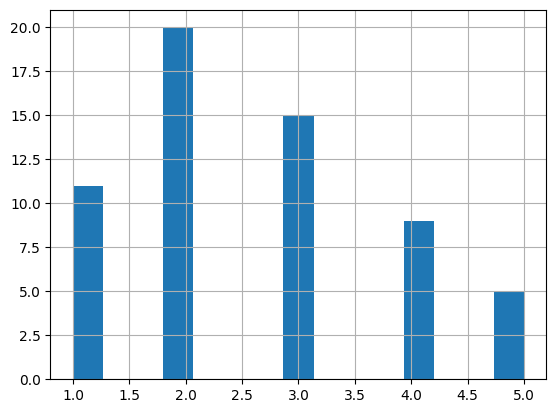

In [10]:
handles_per_actor = identifiers[identifiers["identifier_type"]=="handle"].groupby("actor_id")["identifier_value"].nunique()
wallets_per_actor = identifiers[identifiers["identifier_type"]=="wallet"].groupby("actor_id")["identifier_value"].nunique()

print("Handles per actor — describe:\n", handles_per_actor.describe())
print("\nWallets per actor — describe:\n", wallets_per_actor.describe())

handles_per_actor.hist(bins=15)

In [11]:
wallet_owner_counts = identifiers[identifiers["identifier_type"]=="wallet"].groupby("identifier_value")["actor_id"].nunique()
shared_wallets = wallet_owner_counts[wallet_owner_counts > 1]
print(f"Wallets shared by multiple actors: {len(shared_wallets)}")
print(shared_wallets.head(10))

handle_owner_counts = identifiers[identifiers["identifier_type"]=="handle"].groupby("identifier_value")["actor_id"].nunique()
shared_handles = handle_owner_counts[handle_owner_counts > 1]
print(f"\nHandles shared by multiple actors: {len(shared_handles)}")
print(shared_handles.head(10))

Wallets shared by multiple actors: 0
Series([], Name: actor_id, dtype: int64)

Handles shared by multiple actors: 1
identifier_value
ShadowForge    2
Name: actor_id, dtype: int64


In [12]:
print(timeline["event_type"].value_counts())

migration_events = timeline[timeline["event_type"].isin(["MIGRATION", "HANDLE_CHANGE"])]
print(f"\nTotal migration/handle-change events: {len(migration_events)}")
display(migration_events.head(10))
print("\nActors with migration events:", migration_events["actor_id"].nunique())

event_type
POST                     2990
LOGIN                    2208
REPLY                    1506
MESSAGE                  1206
LISTING                   976
WALLET_ACTIVITY           798
PROFILE_UPDATE            512
HANDLE_CHANGE              97
INFRASTRUCTURE_CHANGE      85
IDENTIFIER_UPDATE          72
MIGRATION                  55
Name: count, dtype: int64

Total migration/handle-change events: 152


,event_id,actor_id,handle,event_type,timestamp,source_id,description,metadata,confidence
498,EVT_000499,ACT_0003,IronLedger,HANDLE_CHANGE,2025-11-10T18:21:03Z,SRC_000418,Handle changed from GreyRoot to IronLedger.,"{""from_handle"": ""GreyRoot"", ""to_handle"": ""Iron...",0.52
768,EVT_000769,ACT_0005,CipherHollow,HANDLE_CHANGE,2026-09-12T00:00:00Z,SRC_001602,Handle changed from SilentVector to CipherHollow.,"{""from_handle"": ""SilentVector"", ""to_handle"": ""...",0.84
769,EVT_000770,ACT_0005,CipherHollow,MIGRATION,2026-09-17T00:00:00Z,SRC_000923,Migration signal observed following handle cha...,"{""migration_stage"": ""post-handle-change""}",0.44
946,EVT_000947,ACT_0006,ForgeVector,HANDLE_CHANGE,2024-08-15T08:56:39Z,SRC_000191,Handle changed from ShadowForge to ForgeVector.,"{""from_handle"": ""ShadowForge"", ""to_handle"": ""F...",0.88
947,EVT_000948,ACT_0006,ForgeVector,MIGRATION,2024-08-20T08:56:39Z,SRC_004213,Migration signal observed following handle cha...,"{""migration_stage"": ""post-handle-change""}",0.59
953,EVT_000954,ACT_0006,RogueRoot,HANDLE_CHANGE,2025-09-05T08:56:39Z,SRC_001653,Handle changed from ForgeVector to RogueRoot.,"{""from_handle"": ""ForgeVector"", ""to_handle"": ""R...",0.92
1136,EVT_001137,ACT_0007,IronWolf81,HANDLE_CHANGE,2024-11-26T13:12:42Z,SRC_002638,Handle changed from GhostForge71 to IronWolf81.,"{""from_handle"": ""GhostForge71"", ""to_handle"": ""...",0.92
1137,EVT_001138,ACT_0007,IronWolf81,MIGRATION,2024-11-29T13:12:42Z,SRC_000092,Migration signal observed following handle cha...,"{""migration_stage"": ""post-handle-change""}",0.57
1254,EVT_001255,ACT_0008,IronCrow,HANDLE_CHANGE,2025-04-05T10:13:36Z,SRC_002322,Handle changed from RuneLedger to IronCrow.,"{""from_handle"": ""RuneLedger"", ""to_handle"": ""Ir...",0.93
1255,EVT_001256,ACT_0008,IronCrow,MIGRATION,2025-04-06T10:13:36Z,SRC_002724,Migration signal observed following handle cha...,"{""migration_stage"": ""post-handle-change""}",0.81



Actors with migration events: 49


,avg_sentence_length,punctuation_ratio,technical_term_ratio,sentiment_score
count,60.000000,60.000000,60.000000,60.000000
mean,10.158718,0.160673,0.017810,0.005593
std,3.764754,0.112514,0.005465,0.038466
min,5.836019,0.030774,0.007185,-0.090187
25%,7.777066,0.090528,0.014216,-0.016738
50%,8.442410,0.127791,0.017813,0.005204
75%,13.427177,0.226295,0.020938,0.032572
max,19.778594,0.467245,0.037327,0.151481


<Axes: >

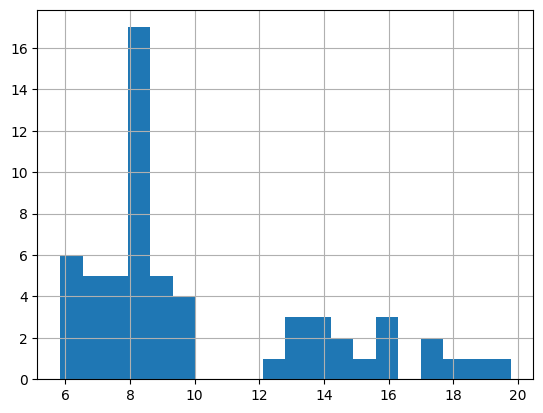

In [13]:
style_by_actor = posts.groupby("actor_id")[["avg_sentence_length", "punctuation_ratio", "technical_term_ratio", "sentiment_score"]].mean()
display(style_by_actor.describe())
style_by_actor["avg_sentence_length"].hist(bins=20)

In [14]:
sf_rows = identifiers[identifiers["identifier_value"] == "ShadowForge"]
display(sf_rows[["actor_id", "first_seen", "last_seen", "status"]].sort_values("first_seen"))

,actor_id,first_seen,last_seen,status
4988,ACT_0006,2024-02-19T08:56:39Z,2024-07-06T08:56:39Z,duplicate_observation
3044,ACT_0006,2024-02-19T08:56:39Z,2024-06-30T08:56:39Z,duplicate_observation
5129,ACT_0006,2024-02-19T08:56:39Z,2024-07-08T08:56:39Z,duplicate_observation
4504,ACT_0006,2024-02-20T08:56:39Z,2024-07-13T08:56:39Z,duplicate_observation
2407,ACT_0006,2024-02-20T08:56:39Z,2024-07-11T08:56:39Z,duplicate_observation
3533,ACT_0006,2024-02-21T08:56:39Z,2024-06-30T08:56:39Z,duplicate_observation
12,ACT_0006,2024-02-22T08:56:39Z,2024-07-08T08:56:39Z,superseded
4872,ACT_0006,2024-02-22T08:56:39Z,2024-07-04T08:56:39Z,duplicate_observation
2230,ACT_0006,2024-02-22T08:56:39Z,2024-07-14T08:56:39Z,duplicate_observation
5192,ACT_0006,2024-02-23T08:56:39Z,2024-07-03T08:56:39Z,duplicate_observation


In [15]:
import json

handle_changes = timeline[timeline["event_type"] == "HANDLE_CHANGE"].copy()
handle_changes["from_handle"] = handle_changes["metadata"].apply(lambda m: json.loads(m).get("from_handle"))
handle_changes["to_handle"] = handle_changes["metadata"].apply(lambda m: json.loads(m).get("to_handle"))

migration_chain = handle_changes[["actor_id", "from_handle", "to_handle", "timestamp", "confidence"]].sort_values(["actor_id", "timestamp"])
display(migration_chain)

print(migration_chain[(migration_chain["from_handle"] == "ShadowForge") | (migration_chain["to_handle"] == "ShadowForge")])

,actor_id,from_handle,to_handle,timestamp,confidence
498,ACT_0003,GreyRoot,IronLedger,2025-11-10T18:21:03Z,0.52
768,ACT_0005,SilentVector,CipherHollow,2026-09-12T00:00:00Z,0.84
946,ACT_0006,ShadowForge,ForgeVector,2024-08-15T08:56:39Z,0.88
953,ACT_0006,ForgeVector,RogueRoot,2025-09-05T08:56:39Z,0.92
1136,ACT_0007,GhostForge71,IronWolf81,2024-11-26T13:12:42Z,0.92
...,...,...,...,...,...
9683,ACT_0056,AshShade20,VoidCipher,2026-10-08T00:00:00Z,0.89
9889,ACT_0057,CrimsonDrift,DriftReaper,2026-09-16T00:00:00Z,0.70
9981,ACT_0058,PhantomDrift95,DarkSignal,2025-12-27T17:09:54Z,0.69
10169,ACT_0059,FrostRunner37,VectorHex,2026-09-20T00:00:00Z,0.76


      actor_id  from_handle    to_handle             timestamp  confidence
946   ACT_0006  ShadowForge  ForgeVector  2024-08-15T08:56:39Z        0.88
3334  ACT_0021  ShadowForge    NullPulse  2026-09-18T00:00:00Z        0.53


In [16]:
# Which actors are seen sending/receiving from each wallet, across BOTH wallet columns
from_map = wallet_tx.dropna(subset=["actor_from"])[["from_wallet", "actor_from"]].rename(columns={"from_wallet":"wallet","actor_from":"actor"})
to_map = wallet_tx.dropna(subset=["actor_to"])[["to_wallet", "actor_to"]].rename(columns={"to_wallet":"wallet","actor_to":"actor"})
wallet_actor_links = pd.concat([from_map, to_map]).drop_duplicates()

wallet_actor_counts = wallet_actor_links.groupby("wallet")["actor"].nunique()
shared_via_tx = wallet_actor_counts[wallet_actor_counts > 1]
print(f"Wallets linked to multiple actors via transactions: {len(shared_via_tx)}")
print(shared_via_tx.head(10))

Wallets linked to multiple actors via transactions: 0
Series([], Name: actor, dtype: int64)


In [17]:
print("Unique transaction clusters:", wallet_tx["transaction_cluster"].nunique())
print(wallet_tx["transaction_cluster"].dropna().unique()[:20])

# Clusters that reference two different actor IDs in their name (like the STRO one you saw)
import re
multi_actor_clusters = wallet_tx["transaction_cluster"].dropna().unique()
multi_actor_clusters = [c for c in multi_actor_clusters if len(re.findall(r"ACT_\d+", c)) > 1]
print(f"\nClusters naming multiple actors: {len(multi_actor_clusters)}")
print(multi_actor_clusters[:15])

Unique transaction clusters: 71
['CLUSTER_STRO_ACT_0001_ACT_0017' 'CLUSTER_MEDI_ACT_0004_ACT_0022'
 'CLUSTER_SHAR_ACT_0015_ACT_0037' 'CLUSTER_STRO_ACT_0025_ACT_0047'
 'CLUSTER_STRO_ACT_0002_ACT_0057' 'CLUSTER_MEDI_ACT_0014_ACT_0059'
 'CLUSTER_MEDI_ACT_0050_ACT_0030' 'CLUSTER_MEDI_ACT_0036_ACT_0016'
 'CLUSTER_MEDI_ACT_0034_ACT_0045' 'CLUSTER_SHAR_ACT_0049_ACT_0042'
 'CLUSTER_SHAR_ACT_0052_ACT_0019' 'TXCLUSTER_002' 'TXCLUSTER_003'
 'TXCLUSTER_004' 'TXCLUSTER_005' 'TXCLUSTER_006' 'TXCLUSTER_007'
 'TXCLUSTER_008' 'TXCLUSTER_009' 'TXCLUSTER_010']

Clusters naming multiple actors: 11
['CLUSTER_STRO_ACT_0001_ACT_0017', 'CLUSTER_MEDI_ACT_0004_ACT_0022', 'CLUSTER_SHAR_ACT_0015_ACT_0037', 'CLUSTER_STRO_ACT_0025_ACT_0047', 'CLUSTER_STRO_ACT_0002_ACT_0057', 'CLUSTER_MEDI_ACT_0014_ACT_0059', 'CLUSTER_MEDI_ACT_0050_ACT_0030', 'CLUSTER_MEDI_ACT_0036_ACT_0016', 'CLUSTER_MEDI_ACT_0034_ACT_0045', 'CLUSTER_SHAR_ACT_0049_ACT_0042', 'CLUSTER_SHAR_ACT_0052_ACT_0019']


In [18]:
import networkx as nx

G = nx.Graph()
for _, row in wallet_tx.iterrows():
    G.add_edge(row["from_wallet"], row["to_wallet"])

components = list(nx.connected_components(G))
print(f"Total connected wallet components: {len(components)}")

# For each component, find which actors touch it (via actor_from/actor_to)
wallet_to_actor = pd.concat([
    wallet_tx.dropna(subset=["actor_from"])[["from_wallet","actor_from"]].rename(columns={"from_wallet":"wallet","actor_from":"actor"}),
    wallet_tx.dropna(subset=["actor_to"])[["to_wallet","actor_to"]].rename(columns={"to_wallet":"wallet","actor_to":"actor"})
]).drop_duplicates()

multi_actor_components = []
for comp in components:
    actors_in_comp = wallet_to_actor[wallet_to_actor["wallet"].isin(comp)]["actor"].unique()
    if len(actors_in_comp) > 1:
        multi_actor_components.append((comp, actors_in_comp))

print(f"\nConnected components touching multiple actors: {len(multi_actor_components)}")
for comp, actors in multi_actor_components[:5]:
    print(f"  {len(comp)} wallets, actors: {actors}")

Total connected wallet components: 1

Connected components touching multiple actors: 1
  220 wallets, actors: ['ACT_0001' 'ACT_0004' 'ACT_0015' 'ACT_0025' 'ACT_0002' 'ACT_0014'
 'ACT_0050' 'ACT_0036' 'ACT_0034' 'ACT_0049' 'ACT_0052' 'ACT_0032'
 'ACT_0027' 'ACT_0038' 'ACT_0011' 'ACT_0037' 'ACT_0043' 'ACT_0042'
 'ACT_0021' 'ACT_0006' 'ACT_0047' 'ACT_0007' 'ACT_0041' 'ACT_0020'
 'ACT_0005' 'ACT_0046' 'ACT_0024' 'ACT_0003' 'ACT_0048' 'ACT_0055'
 'ACT_0057' 'ACT_0009' 'ACT_0030' 'ACT_0023' 'ACT_0054' 'ACT_0016'
 'ACT_0040' 'ACT_0053' 'ACT_0031' 'ACT_0017' 'ACT_0044' 'ACT_0058'
 'ACT_0051' 'ACT_0018' 'ACT_0026' 'ACT_0008' 'ACT_0019' 'ACT_0012'
 'ACT_0013' 'ACT_0045' 'ACT_0010' 'ACT_0022' 'ACT_0059' 'ACT_0033'
 'ACT_0035' 'ACT_0039' 'ACT_0029' 'ACT_0060' 'ACT_0056' 'ACT_0028']


In [19]:
# Direct wallet-to-wallet edges only — who's directly connected without long chains
direct_edges = wallet_tx[["from_wallet", "to_wallet"]].drop_duplicates()

# Map each wallet to its actor(s)
wallet_actors = wallet_to_actor.groupby("wallet")["actor"].apply(set).to_dict()

direct_actor_pairs = set()
for _, row in direct_edges.iterrows():
    actors_a = wallet_actors.get(row["from_wallet"], set())
    actors_b = wallet_actors.get(row["to_wallet"], set())
    for a in actors_a:
        for b in actors_b:
            if a != b:
                direct_actor_pairs.add(tuple(sorted([a, b])))

print(f"Actor pairs with a DIRECT wallet transaction between them: {len(direct_actor_pairs)}")
for pair in list(direct_actor_pairs)[:15]:
    print(pair)

Actor pairs with a DIRECT wallet transaction between them: 1201
('ACT_0011', 'ACT_0053')
('ACT_0037', 'ACT_0040')
('ACT_0028', 'ACT_0048')
('ACT_0016', 'ACT_0046')
('ACT_0001', 'ACT_0040')
('ACT_0006', 'ACT_0025')
('ACT_0042', 'ACT_0043')
('ACT_0003', 'ACT_0037')
('ACT_0017', 'ACT_0043')
('ACT_0021', 'ACT_0055')
('ACT_0002', 'ACT_0026')
('ACT_0003', 'ACT_0030')
('ACT_0018', 'ACT_0024')
('ACT_0018', 'ACT_0032')
('ACT_0012', 'ACT_0024')


In [20]:
# For a sample of actor pairs, compute shortest path length between their wallet sets
import itertools

sample_actors = list(wallet_to_actor["actor"].unique())[:10]  # small sample first, to check runtime
actor_wallets = wallet_to_actor.groupby("actor")["wallet"].apply(list).to_dict()

path_lengths = {}
for a, b in itertools.combinations(sample_actors, 2):
    min_dist = float("inf")
    for wa in actor_wallets[a][:3]:      # limit to avoid huge runtime
        for wb in actor_wallets[b][:3]:
            if nx.has_path(G, wa, wb):
                d = nx.shortest_path_length(G, wa, wb)
                min_dist = min(min_dist, d)
    path_lengths[(a, b)] = min_dist

print(pd.Series(path_lengths).sort_values().head(15))

ACT_0001  ACT_0004    1
          ACT_0015    1
          ACT_0025    1
          ACT_0002    1
          ACT_0014    1
          ACT_0050    1
          ACT_0034    1
          ACT_0049    1
ACT_0004  ACT_0014    1
          ACT_0015    1
          ACT_0025    1
          ACT_0002    1
          ACT_0036    1
          ACT_0050    1
          ACT_0034    1
dtype: int64


In [21]:
print("Total unique clusters:", wallet_tx["transaction_cluster"].nunique())
print("\nSample cluster names:")
print(wallet_tx["transaction_cluster"].dropna().unique()[:20])

# Extract the prefix pattern (e.g. STRO, MED, etc.) before the actor IDs
import re
def extract_prefix(cluster):
    match = re.match(r"CLUSTER_([A-Z]+)_", str(cluster))
    return match.group(1) if match else None

wallet_tx["cluster_prefix"] = wallet_tx["transaction_cluster"].apply(extract_prefix)
print("\nCluster prefix counts:")
print(wallet_tx["cluster_prefix"].value_counts())

Total unique clusters: 71

Sample cluster names:
['CLUSTER_STRO_ACT_0001_ACT_0017' 'CLUSTER_MEDI_ACT_0004_ACT_0022'
 'CLUSTER_SHAR_ACT_0015_ACT_0037' 'CLUSTER_STRO_ACT_0025_ACT_0047'
 'CLUSTER_STRO_ACT_0002_ACT_0057' 'CLUSTER_MEDI_ACT_0014_ACT_0059'
 'CLUSTER_MEDI_ACT_0050_ACT_0030' 'CLUSTER_MEDI_ACT_0036_ACT_0016'
 'CLUSTER_MEDI_ACT_0034_ACT_0045' 'CLUSTER_SHAR_ACT_0049_ACT_0042'
 'CLUSTER_SHAR_ACT_0052_ACT_0019' 'TXCLUSTER_002' 'TXCLUSTER_003'
 'TXCLUSTER_004' 'TXCLUSTER_005' 'TXCLUSTER_006' 'TXCLUSTER_007'
 'TXCLUSTER_008' 'TXCLUSTER_009' 'TXCLUSTER_010']

Cluster prefix counts:
cluster_prefix
MEDI    35
SHAR    27
STRO    22
Name: count, dtype: int64


In [22]:
def extract_actor_pair(cluster):
    if pd.isna(cluster):
        return None
    actors = re.findall(r"ACT_\d+", cluster)
    return tuple(sorted(set(actors))) if len(set(actors)) > 1 else None

wallet_tx["cluster_actor_pair"] = wallet_tx["transaction_cluster"].apply(extract_actor_pair)
named_pairs = wallet_tx.dropna(subset=["cluster_actor_pair"])[["cluster_actor_pair", "cluster_prefix"]].drop_duplicates()
print(f"Distinct named actor-pairs in clusters: {len(named_pairs)}")
display(named_pairs)

Distinct named actor-pairs in clusters: 11


,cluster_actor_pair,cluster_prefix
0,"(ACT_0001, ACT_0017)",STRO
8,"(ACT_0004, ACT_0022)",MEDI
16,"(ACT_0015, ACT_0037)",SHAR
26,"(ACT_0025, ACT_0047)",STRO
33,"(ACT_0002, ACT_0057)",STRO
40,"(ACT_0014, ACT_0059)",MEDI
46,"(ACT_0030, ACT_0050)",MEDI
54,"(ACT_0016, ACT_0036)",MEDI
61,"(ACT_0034, ACT_0045)",MEDI
67,"(ACT_0042, ACT_0049)",SHAR


In [23]:
cluster_summary = wallet_tx.dropna(subset=["cluster_actor_pair"]).groupby("cluster_prefix").agg(
    mean_confidence=("confidence", "mean"),
    mean_amount=("amount", "mean"),
    n_transactions=("transaction_id", "count"),
    risk_signals=("risk_signal", lambda x: x.value_counts().to_dict())
)
display(cluster_summary)

,mean_confidence,mean_amount,n_transactions,risk_signals
cluster_prefix,,,,
MEDI,0.575143,1.339548,35,{'medium': 35}
SHAR,0.571852,1.297364,27,{'medium': 27}
STRO,0.591364,1.255741,22,{'medium': 22}


In [24]:
for a, b in named_pairs[named_pairs["cluster_prefix"]=="SHAR"]["cluster_actor_pair"]:
    a_ids = set(identifiers[identifiers["actor_id"]==a]["identifier_value"])
    b_ids = set(identifiers[identifiers["actor_id"]==b]["identifier_value"])
    print(f"{a} vs {b} — shared identifiers: {a_ids & b_ids}")

ACT_0015 vs ACT_0037 — shared identifiers: set()
ACT_0042 vs ACT_0049 — shared identifiers: set()
ACT_0019 vs ACT_0052 — shared identifiers: set()


In [25]:
for prefix in ["STRO", "MEDI"]:
    print(f"\n=== {prefix} pairs ===")
    for a, b in named_pairs[named_pairs["cluster_prefix"]==prefix]["cluster_actor_pair"]:
        a_ids = set(identifiers[identifiers["actor_id"]==a]["identifier_value"])
        b_ids = set(identifiers[identifiers["actor_id"]==b]["identifier_value"])
        style_a = style_by_actor.loc[a] if a in style_by_actor.index else None
        style_b = style_by_actor.loc[b] if b in style_by_actor.index else None
        style_dist = None
        if style_a is not None and style_b is not None:
            style_dist = ((style_a - style_b)**2).sum()**0.5
        print(f"{a} vs {b} — shared identifiers: {a_ids & b_ids} | stylometric distance: {style_dist:.3f}" if style_dist is not None else f"{a} vs {b} — shared identifiers: {a_ids & b_ids}")


=== STRO pairs ===
ACT_0001 vs ACT_0017 — shared identifiers: {'PGP_SYN_0094'} | stylometric distance: 1.047
ACT_0025 vs ACT_0047 — shared identifiers: {'PGP_SYN_0054'} | stylometric distance: 1.391
ACT_0002 vs ACT_0057 — shared identifiers: {'PGP_SYN_0091'} | stylometric distance: 6.728

=== MEDI pairs ===
ACT_0004 vs ACT_0022 — shared identifiers: set() | stylometric distance: 1.473
ACT_0014 vs ACT_0059 — shared identifiers: set() | stylometric distance: 2.445
ACT_0030 vs ACT_0050 — shared identifiers: set() | stylometric distance: 1.928
ACT_0016 vs ACT_0036 — shared identifiers: set() | stylometric distance: 12.501
ACT_0034 vs ACT_0045 — shared identifiers: set() | stylometric distance: 0.207


In [26]:
# Does infrastructure indicator_value/match_target overlap for known pairs?
for prefix in ["STRO", "MEDI", "SHAR"]:
    print(f"\n=== {prefix} pairs — infrastructure overlap ===")
    for a, b in named_pairs[named_pairs["cluster_prefix"]==prefix]["cluster_actor_pair"]:
        infra_a = set(infra[infra["actor_id"]==a]["match_target"].dropna())
        infra_b = set(infra[infra["actor_id"]==b]["match_target"].dropna())
        print(f"{a} vs {b} — shared infra clusters: {infra_a & infra_b}")


=== STRO pairs — infrastructure overlap ===
ACT_0001 vs ACT_0017 — shared infra clusters: {'INFRA_CLUSTER_08'}
ACT_0025 vs ACT_0047 — shared infra clusters: {'INFRA_CLUSTER_36'}
ACT_0002 vs ACT_0057 — shared infra clusters: {'INFRA_CLUSTER_12'}

=== MEDI pairs — infrastructure overlap ===
ACT_0004 vs ACT_0022 — shared infra clusters: set()
ACT_0014 vs ACT_0059 — shared infra clusters: set()
ACT_0030 vs ACT_0050 — shared infra clusters: set()
ACT_0016 vs ACT_0036 — shared infra clusters: set()
ACT_0034 vs ACT_0045 — shared infra clusters: set()

=== SHAR pairs — infrastructure overlap ===
ACT_0015 vs ACT_0037 — shared infra clusters: set()
ACT_0042 vs ACT_0049 — shared infra clusters: set()
ACT_0019 vs ACT_0052 — shared infra clusters: set()


In [27]:
import re

def extract_actor_pair_infra(val):
    if pd.isna(val):
        return None
    actors = re.findall(r"ACT_\d+", str(val))
    return tuple(sorted(set(actors))) if len(set(actors)) > 1 else None

# Check both indicator_value and match_target for embedded actor-pair naming
infra["pair_from_value"] = infra["indicator_value"].apply(extract_actor_pair_infra)
infra["pair_from_target"] = infra["match_target"].apply(extract_actor_pair_infra)

print("Actor pairs named in indicator_value:", infra["pair_from_value"].dropna().unique())
print("Actor pairs named in match_target:", infra["pair_from_target"].dropna().unique())

# Also look at match_target's naming pattern generally
print("\nSample match_target values:")
print(infra["match_target"].dropna().unique()[:15])

Actor pairs named in indicator_value: []
Actor pairs named in match_target: []

Sample match_target values:
['INFRA_CLUSTER_33' 'INFRA_CLUSTER_26' 'INFRA_CLUSTER_05'
 'INFRA_CLUSTER_36' 'INFRA_CLUSTER_38' 'INFRA_CLUSTER_25'
 'INFRA_CLUSTER_24' 'INFRA_CLUSTER_03' 'INFRA_CLUSTER_19'
 'INFRA_CLUSTER_21' 'INFRA_CLUSTER_07' 'INFRA_CLUSTER_10'
 'INFRA_CLUSTER_08' 'INFRA_CLUSTER_15' 'INFRA_CLUSTER_28']


In [28]:
import numpy as np
import json

# Stylometric profile
style_profile = posts.groupby("actor_id")[
    ["avg_sentence_length", "punctuation_ratio", "technical_term_ratio", "sentiment_score"]
].mean()

# Behavioral profile: posting-hour distribution per actor (from timeline metadata)
def get_hour(metadata_str):
    try:
        return json.loads(metadata_str).get("hour")
    except Exception:
        return None

timeline["hour"] = timeline["metadata"].apply(get_hour)
hour_dist = timeline.dropna(subset=["hour"]).groupby("actor_id")["hour"].apply(
    lambda hours: np.histogram(hours, bins=24, range=(0,24), density=True)[0]
)

# Identifier sets per actor, split by type
def id_set(actor_id, id_type):
    return set(identifiers[(identifiers["actor_id"]==actor_id) & (identifiers["identifier_type"]==id_type)]["identifier_value"])

actors = sorted(identifiers["actor_id"].unique())
pgp_sets = {a: id_set(a, "pgp") for a in actors}
handle_sets = {a: id_set(a, "handle") for a in actors}
wallet_sets = {a: id_set(a, "wallet") for a in actors}

# Infra sets per actor
infra_sets = {a: set(infra[infra["actor_id"]==a]["match_target"].dropna()) for a in actors}

print("Actors profiled:", len(actors))
print("Sample PGP set:", list(pgp_sets.items())[:2])

Actors profiled: 60
Sample PGP set: [('ACT_0001', {'PGP_SYN_0094'}), ('ACT_0002', {'PGP_SYN_0091'})]


In [29]:
from itertools import combinations
from scipy.spatial.distance import euclidean, cosine

def compute_features(a, b):
    feats = {}

    # Stylometric distance (validated: real but noisy signal)
    if a in style_profile.index and b in style_profile.index:
        feats["stylometric_distance"] = euclidean(style_profile.loc[a], style_profile.loc[b])
    else:
        feats["stylometric_distance"] = np.nan

    # Behavioral similarity (posting-hour pattern)
    if a in hour_dist.index and b in hour_dist.index:
        feats["behavior_similarity"] = 1 - cosine(hour_dist[a], hour_dist[b])
    else:
        feats["behavior_similarity"] = np.nan

    # Shared PGP (validated: your strongest clean signal)
    feats["shared_pgp"] = int(len(pgp_sets[a] & pgp_sets[b]) > 0)

    # Shared infra cluster (validated: strong, mirrors PGP)
    feats["shared_infra"] = int(len(infra_sets[a] & infra_sets[b]) > 0)

    # Shared wallet-transaction cluster (validated: needs corroboration, not standalone)
    cluster_a = set(wallet_tx[wallet_tx["actor_from"]==a]["transaction_cluster"].dropna()) | \
                set(wallet_tx[wallet_tx["actor_to"]==a]["transaction_cluster"].dropna())
    cluster_b = set(wallet_tx[wallet_tx["actor_from"]==b]["transaction_cluster"].dropna()) | \
                set(wallet_tx[wallet_tx["actor_to"]==b]["transaction_cluster"].dropna())
    feats["shared_wallet_cluster"] = int(len(cluster_a & cluster_b) > 0)

    # Shared handle WITH temporal overlap (validated: raw shared handle alone is unsafe — ShadowForge case)
    shared_handle_overlap = 0
    for h in handle_sets[a] & handle_sets[b]:
        rows_a = identifiers[(identifiers["actor_id"]==a) & (identifiers["identifier_value"]==h)]
        rows_b = identifiers[(identifiers["actor_id"]==b) & (identifiers["identifier_value"]==h)]
        for _, ra in rows_a.iterrows():
            for _, rb in rows_b.iterrows():
                if not (ra["last_seen"] < rb["first_seen"] or rb["last_seen"] < ra["first_seen"]):
                    shared_handle_overlap = 1
    feats["shared_handle_with_overlap"] = shared_handle_overlap

    # Evidence count (validated conclusion: verdict should scale with # of corroborating types)
    feats["evidence_count"] = feats["shared_pgp"] + feats["shared_infra"] + feats["shared_handle_with_overlap"]

    return feats

In [30]:
rows = []
for a, b in combinations(actors, 2):
    f = compute_features(a, b)
    f["actor_a"] = a
    f["actor_b"] = b
    rows.append(f)

pair_features = pd.DataFrame(rows)
print("Total pairs:", len(pair_features))
pair_features.head()

Total pairs: 1770


,stylometric_distance,behavior_similarity,shared_pgp,shared_infra,shared_wallet_cluster,shared_handle_with_overlap,evidence_count,actor_a,actor_b
0,0.189202,0.213351,0,0,1,0,0,ACT_0001,ACT_0002
1,0.481201,0.939921,0,0,1,0,0,ACT_0001,ACT_0003
2,1.670647,0.876262,0,0,1,0,0,ACT_0001,ACT_0004
3,1.556418,0.884903,0,0,1,0,0,ACT_0001,ACT_0005
4,5.256923,0.205816,0,0,1,0,0,ACT_0001,ACT_0006


In [31]:
wallet_to_actor = pd.concat([
    wallet_tx.dropna(subset=["actor_from"])[["from_wallet","actor_from"]].rename(columns={"from_wallet":"wallet","actor_from":"actor"}),
    wallet_tx.dropna(subset=["actor_to"])[["to_wallet","actor_to"]].rename(columns={"to_wallet":"wallet","actor_to":"actor"})
]).drop_duplicates()
cluster_actor_counts = wallet_to_actor.groupby("wallet")["actor"].nunique()

# How many actors touch each transaction_cluster value overall?
cluster_membership = wallet_tx.dropna(subset=["transaction_cluster"]).groupby("transaction_cluster").apply(
    lambda df: set(df["actor_from"].dropna()) | set(df["actor_to"].dropna())
)
cluster_sizes = cluster_membership.apply(len)
print(cluster_sizes.sort_values(ascending=False).head(15))

transaction_cluster
TXCLUSTER_017    21
TXCLUSTER_053    19
TXCLUSTER_018    18
TXCLUSTER_005    18
TXCLUSTER_048    18
TXCLUSTER_052    18
TXCLUSTER_021    17
TXCLUSTER_029    17
TXCLUSTER_059    17
TXCLUSTER_031    17
TXCLUSTER_010    17
TXCLUSTER_024    16
TXCLUSTER_012    16
TXCLUSTER_006    16
TXCLUSTER_032    16
dtype: int64


/tmp/ipykernel_1640/4122287146.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_membership = wallet_tx.dropna(subset=["transaction_cluster"]).groupby("transaction_cluster").apply(


In [32]:
import re

def extract_actor_pair(cluster):
    if pd.isna(cluster):
        return None
    actors_found = re.findall(r"ACT_\d+", str(cluster))
    return tuple(sorted(set(actors_found))) if len(set(actors_found)) > 1 else None

wallet_tx["cluster_actor_pair"] = wallet_tx["transaction_cluster"].apply(extract_actor_pair)
named_cluster_values = set(wallet_tx.dropna(subset=["cluster_actor_pair"])["transaction_cluster"])
print("Named (meaningful) clusters:", named_cluster_values)

def get_named_clusters(actor):
    a_clusters = set(wallet_tx[wallet_tx["actor_from"]==actor]["transaction_cluster"].dropna()) | \
                 set(wallet_tx[wallet_tx["actor_to"]==actor]["transaction_cluster"].dropna())
    return a_clusters & named_cluster_values

named_wallet_clusters = {a: get_named_clusters(a) for a in actors}

Named (meaningful) clusters: {'CLUSTER_STRO_ACT_0025_ACT_0047', 'CLUSTER_MEDI_ACT_0036_ACT_0016', 'CLUSTER_MEDI_ACT_0034_ACT_0045', 'CLUSTER_STRO_ACT_0002_ACT_0057', 'CLUSTER_SHAR_ACT_0015_ACT_0037', 'CLUSTER_SHAR_ACT_0052_ACT_0019', 'CLUSTER_STRO_ACT_0001_ACT_0017', 'CLUSTER_MEDI_ACT_0004_ACT_0022', 'CLUSTER_MEDI_ACT_0050_ACT_0030', 'CLUSTER_MEDI_ACT_0014_ACT_0059', 'CLUSTER_SHAR_ACT_0049_ACT_0042'}


In [33]:
def get_named_clusters(actor):
    a_clusters = set(wallet_tx[wallet_tx["actor_from"]==actor]["transaction_cluster"].dropna()) | \
                 set(wallet_tx[wallet_tx["actor_to"]==actor]["transaction_cluster"].dropna())
    return a_clusters & named_cluster_values

named_wallet_clusters = {a: get_named_clusters(a) for a in actors}

In [34]:
def compute_features(a, b):
    feats = {}

    if a in style_profile.index and b in style_profile.index:
        feats["stylometric_distance"] = euclidean(style_profile.loc[a], style_profile.loc[b])
    else:
        feats["stylometric_distance"] = np.nan

    if a in hour_dist.index and b in hour_dist.index:
        feats["behavior_similarity"] = 1 - cosine(hour_dist[a], hour_dist[b])
    else:
        feats["behavior_similarity"] = np.nan

    feats["shared_pgp"] = int(len(pgp_sets[a] & pgp_sets[b]) > 0)
    feats["shared_infra"] = int(len(infra_sets[a] & infra_sets[b]) > 0)
    feats["shared_wallet_cluster"] = int(len(named_wallet_clusters[a] & named_wallet_clusters[b]) > 0)

    shared_handle_overlap = 0
    for h in handle_sets[a] & handle_sets[b]:
        rows_a = identifiers[(identifiers["actor_id"]==a) & (identifiers["identifier_value"]==h)]
        rows_b = identifiers[(identifiers["actor_id"]==b) & (identifiers["identifier_value"]==h)]
        for _, ra in rows_a.iterrows():
            for _, rb in rows_b.iterrows():
                if not (ra["last_seen"] < rb["first_seen"] or rb["last_seen"] < ra["first_seen"]):
                    shared_handle_overlap = 1
    feats["shared_handle_with_overlap"] = shared_handle_overlap

    feats["evidence_count"] = feats["shared_pgp"] + feats["shared_infra"] + feats["shared_handle_with_overlap"]

    return feats

rows = []
for a, b in combinations(actors, 2):
    f = compute_features(a, b)
    f["actor_a"] = a
    f["actor_b"] = b
    rows.append(f)

pair_features = pd.DataFrame(rows)
print("Total pairs:", len(pair_features))
print("\nPairs with shared_wallet_cluster=1:", pair_features["shared_wallet_cluster"].sum())
pair_features.head()

Total pairs: 1770

Pairs with shared_wallet_cluster=1: 11


,stylometric_distance,behavior_similarity,shared_pgp,shared_infra,shared_wallet_cluster,shared_handle_with_overlap,evidence_count,actor_a,actor_b
0,0.189202,0.213351,0,0,0,0,0,ACT_0001,ACT_0002
1,0.481201,0.939921,0,0,0,0,0,ACT_0001,ACT_0003
2,1.670647,0.876262,0,0,0,0,0,ACT_0001,ACT_0004
3,1.556418,0.884903,0,0,0,0,0,ACT_0001,ACT_0005
4,5.256923,0.205816,0,0,0,0,0,ACT_0001,ACT_0006


In [35]:
def extract_actor_pair(cluster):
    if pd.isna(cluster):
        return None
    actors_found = re.findall(r"ACT_\d+", str(cluster))
    return tuple(sorted(set(actors_found))) if len(set(actors_found)) > 1 else None

def extract_prefix(cluster):
    match = re.match(r"CLUSTER_([A-Z]+)_", str(cluster))
    return match.group(1) if match else None

# Make sure both columns exist on wallet_tx
wallet_tx["cluster_actor_pair"] = wallet_tx["transaction_cluster"].apply(extract_actor_pair)
wallet_tx["cluster_prefix"] = wallet_tx["transaction_cluster"].apply(extract_prefix)

named_pairs = wallet_tx.dropna(subset=["cluster_actor_pair"])[["cluster_actor_pair", "cluster_prefix"]].drop_duplicates()
print(f"Named pairs rebuilt: {len(named_pairs)}")
display(named_pairs)

Named pairs rebuilt: 11


,cluster_actor_pair,cluster_prefix
0,"(ACT_0001, ACT_0017)",STRO
8,"(ACT_0004, ACT_0022)",MEDI
16,"(ACT_0015, ACT_0037)",SHAR
26,"(ACT_0025, ACT_0047)",STRO
33,"(ACT_0002, ACT_0057)",STRO
40,"(ACT_0014, ACT_0059)",MEDI
46,"(ACT_0030, ACT_0050)",MEDI
54,"(ACT_0016, ACT_0036)",MEDI
61,"(ACT_0034, ACT_0045)",MEDI
67,"(ACT_0042, ACT_0049)",SHAR


In [36]:
label_map = {}
for a, b in named_pairs[named_pairs["cluster_prefix"].isin(["STRO","MEDI"])]["cluster_actor_pair"]:
    label_map[tuple(sorted([a,b]))] = 1
for a, b in named_pairs[named_pairs["cluster_prefix"]=="SHAR"]["cluster_actor_pair"]:
    label_map[tuple(sorted([a,b]))] = 0

pair_features["pair_key"] = pair_features.apply(lambda r: tuple(sorted([r["actor_a"], r["actor_b"]])), axis=1)
pair_features["label"] = pair_features["pair_key"].map(label_map)

labeled = pair_features.dropna(subset=["label"])
print(f"Labeled pairs: {len(labeled)} out of {len(pair_features)} total")
labeled[["actor_a","actor_b","shared_pgp","shared_infra","shared_wallet_cluster","shared_handle_with_overlap","evidence_count","stylometric_distance","label"]].sort_values("label", ascending=False)

Labeled pairs: 11 out of 1770 total


,actor_a,actor_b,shared_pgp,shared_infra,shared_wallet_cluster,shared_handle_with_overlap,evidence_count,stylometric_distance,label
15,ACT_0001,ACT_0017,1,1,1,0,2,1.047171,1.0
113,ACT_0002,ACT_0057,1,1,1,0,2,6.728402,1.0
191,ACT_0004,ACT_0022,0,0,1,0,0,1.472707,1.0
733,ACT_0014,ACT_0059,0,0,1,0,0,2.445307,1.0
799,ACT_0016,ACT_0036,0,0,1,0,0,12.500709,1.0
1324,ACT_0030,ACT_0050,0,0,1,0,0,1.928195,1.0
1161,ACT_0025,ACT_0047,1,1,1,0,2,1.391251,1.0
1429,ACT_0034,ACT_0045,0,0,1,0,0,0.206961,1.0
756,ACT_0015,ACT_0037,0,0,1,0,0,0.206193,0.0
941,ACT_0019,ACT_0052,0,0,1,0,0,7.148231,0.0


In [37]:
labeled_full = pair_features.dropna(subset=["label"])
labeled_full[["actor_a","actor_b","behavior_similarity","stylometric_distance","evidence_count","label"]].sort_values("label", ascending=False)

,actor_a,actor_b,behavior_similarity,stylometric_distance,evidence_count,label
15,ACT_0001,ACT_0017,0.195044,1.047171,2,1.0
113,ACT_0002,ACT_0057,0.013887,6.728402,2,1.0
191,ACT_0004,ACT_0022,0.891674,1.472707,0,1.0
733,ACT_0014,ACT_0059,0.997842,2.445307,0,1.0
799,ACT_0016,ACT_0036,0.588111,12.500709,0,1.0
1324,ACT_0030,ACT_0050,0.539541,1.928195,0,1.0
1161,ACT_0025,ACT_0047,0.015204,1.391251,2,1.0
1429,ACT_0034,ACT_0045,0.842623,0.206961,0,1.0
756,ACT_0015,ACT_0037,0.328834,0.206193,0,0.0
941,ACT_0019,ACT_0052,0.986438,7.148231,0,0.0


In [38]:
# Weak label: 1 for confirmed pairs, 0 for everything else (weak assumption: most pairs are unrelated)
pair_features["weak_label"] = pair_features["label"].fillna(0)

print(pair_features["weak_label"].value_counts())

weak_label
0.0    1762
1.0       8
Name: count, dtype: int64


In [39]:
!pip install -q sentence-transformers

In [40]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [41]:
import numpy as np

actor_embeddings = {}

for actor_id in actors:
    actor_posts = posts[posts["actor_id"] == actor_id]["content"].dropna().tolist()
    if len(actor_posts) == 0:
        actor_embeddings[actor_id] = None
        continue
    post_vecs = embed_model.encode(actor_posts, show_progress_bar=False)
    actor_embeddings[actor_id] = np.mean(post_vecs, axis=0)  # average embedding = actor's "semantic fingerprint"

print("Actors embedded:", sum(1 for v in actor_embeddings.values() if v is not None))
print("Embedding dimension:", len(next(v for v in actor_embeddings.values() if v is not None)))

Actors embedded: 60
Embedding dimension: 384


In [42]:
from sklearn.metrics.pairwise import cosine_similarity

def embedding_similarity(a, b):
    vec_a, vec_b = actor_embeddings.get(a), actor_embeddings.get(b)
    if vec_a is None or vec_b is None:
        return np.nan
    return float(cosine_similarity(vec_a.reshape(1,-1), vec_b.reshape(1,-1))[0][0])

pair_features["embedding_similarity"] = pair_features.apply(
    lambda r: embedding_similarity(r["actor_a"], r["actor_b"]), axis=1
)

pair_features[["actor_a","actor_b","stylometric_distance","embedding_similarity"]].head()

,actor_a,actor_b,stylometric_distance,embedding_similarity
0,ACT_0001,ACT_0002,0.189202,0.994147
1,ACT_0001,ACT_0003,0.481201,0.960807
2,ACT_0001,ACT_0004,1.670647,0.960570
3,ACT_0001,ACT_0005,1.556418,0.916445
4,ACT_0001,ACT_0006,5.256923,0.941574


In [43]:
labeled_check = pair_features.dropna(subset=["label"])
labeled_check[["actor_a","actor_b","embedding_similarity","stylometric_distance","behavior_similarity","evidence_count","label"]].sort_values("label", ascending=False)

,actor_a,actor_b,embedding_similarity,stylometric_distance,behavior_similarity,evidence_count,label
15,ACT_0001,ACT_0017,0.949366,1.047171,0.195044,2,1.0
113,ACT_0002,ACT_0057,0.933082,6.728402,0.013887,2,1.0
191,ACT_0004,ACT_0022,0.962913,1.472707,0.891674,0,1.0
733,ACT_0014,ACT_0059,0.918970,2.445307,0.997842,0,1.0
799,ACT_0016,ACT_0036,0.938080,12.500709,0.588111,0,1.0
1324,ACT_0030,ACT_0050,0.921850,1.928195,0.539541,0,1.0
1161,ACT_0025,ACT_0047,0.939191,1.391251,0.015204,2,1.0
1429,ACT_0034,ACT_0045,0.961533,0.206961,0.842623,0,1.0
756,ACT_0015,ACT_0037,0.922899,0.206193,0.328834,0,0.0
941,ACT_0019,ACT_0052,0.862416,7.148231,0.986438,0,0.0


In [44]:
#model training
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

feature_cols = ["stylometric_distance", "behavior_similarity", "embedding_similarity",
                 "shared_pgp", "shared_infra", "shared_wallet_cluster",
                 "shared_handle_with_overlap", "evidence_count"]

X = pair_features[feature_cols].fillna(0)
y = pair_features["weak_label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # needed for Logistic Regression; RF doesn't need itm

In [45]:
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_scaled, y)

print("Logistic Regression coefficients:")
for name, coef in sorted(zip(feature_cols, logreg.coef_[0]), key=lambda t: -abs(t[1])):
    print(f"  {name}: {coef:.3f}")

Logistic Regression coefficients:
  shared_wallet_cluster: 1.163
  embedding_similarity: 0.406
  shared_pgp: 0.173
  evidence_count: 0.067
  behavior_similarity: 0.063
  stylometric_distance: 0.059
  shared_infra: 0.026
  shared_handle_with_overlap: 0.000


In [46]:
rf = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced", random_state=42)
rf.fit(X, y)   # RF doesn't need scaling

print("Random Forest feature importances:")
for name, imp in sorted(zip(feature_cols, rf.feature_importances_), key=lambda t: -t[1]):
    print(f"  {name}: {imp:.3f}")

Random Forest feature importances:
  shared_wallet_cluster: 0.561
  embedding_similarity: 0.155
  behavior_similarity: 0.092
  stylometric_distance: 0.073
  shared_pgp: 0.047
  evidence_count: 0.045
  shared_infra: 0.029
  shared_handle_with_overlap: 0.000


In [47]:
labeled_idx = pair_features.dropna(subset=["label"]).index

X_known = X.loc[labeled_idx]
X_known_scaled = scaler.transform(X_known)

validation = pair_features.loc[labeled_idx, ["actor_a","actor_b","label"]].copy()
validation["logreg_probability"] = logreg.predict_proba(X_known_scaled)[:, 1]
validation["rf_probability"] = rf.predict_proba(X_known)[:, 1]

print(validation.sort_values("label", ascending=False))

       actor_a   actor_b  label  logreg_probability  rf_probability
15    ACT_0001  ACT_0017    1.0            0.999983        0.920000
113   ACT_0002  ACT_0057    1.0            0.999982        0.896667
191   ACT_0004  ACT_0022    1.0            0.997615        0.867930
733   ACT_0014  ACT_0059    1.0            0.996647        0.738517
799   ACT_0016  ACT_0036    1.0            0.997433        0.778655
1324  ACT_0030  ACT_0050    1.0            0.996450        0.770593
1161  ACT_0025  ACT_0047    1.0            0.999981        0.932592
1429  ACT_0034  ACT_0045    1.0            0.997515        0.793254
756   ACT_0015  ACT_0037    0.0            0.996254        0.234298
941   ACT_0019  ACT_0052    0.0            0.994981        0.140000
1605  ACT_0042  ACT_0049    0.0            0.998208        0.293585


In [48]:
print("Random Forest feature importances:")
for name, imp in sorted(zip(feature_cols, rf.feature_importances_), key=lambda t: -t[1]):
    print(f"  {name}: {imp:.3f}")

Random Forest feature importances:
  shared_wallet_cluster: 0.561
  embedding_similarity: 0.155
  behavior_similarity: 0.092
  stylometric_distance: 0.073
  shared_pgp: 0.047
  evidence_count: 0.045
  shared_infra: 0.029
  shared_handle_with_overlap: 0.000


In [49]:
print(pair_features["shared_handle_with_overlap"].value_counts())

shared_handle_with_overlap
0    1770
Name: count, dtype: int64


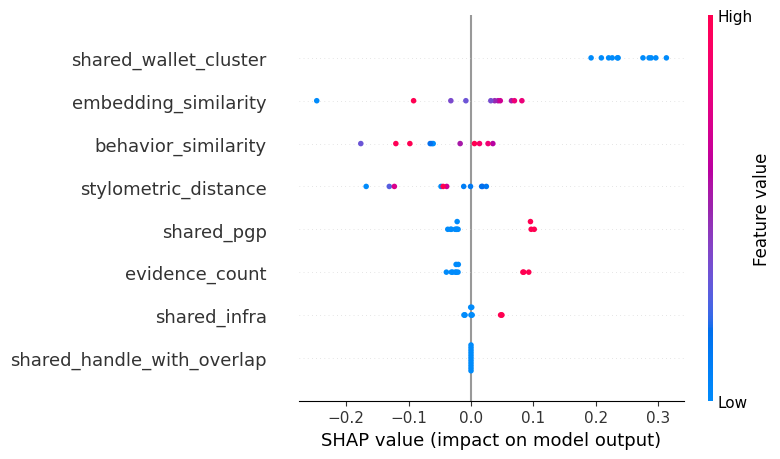

In [50]:
!pip install -q shap
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_known)  # X_known =  11 labeled pairs from before

# shap_values shape depends on sklearn/shap version — this handles both binary-output formats
if isinstance(shap_values, list):
    shap_vals_positive = shap_values[1]
else:
    shap_vals_positive = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

shap.summary_plot(shap_vals_positive, X_known, feature_names=feature_cols)

In [51]:
for i, idx in enumerate(labeled_idx):
    row = pair_features.loc[idx]
    print(f"\n{row['actor_a']} vs {row['actor_b']} — label={row['label']}, RF probability={rf.predict_proba(X.loc[[idx]])[:,1][0]:.3f}")
    contributions = sorted(zip(feature_cols, shap_vals_positive[i]), key=lambda t: -abs(t[1]))
    for name, val in contributions[:3]:
        direction = "pushed UP" if val > 0 else "pushed DOWN"
        print(f"   {name}: {direction} by {abs(val):.3f}")


ACT_0001 vs ACT_0017 — label=1.0, RF probability=0.920
   shared_wallet_cluster: pushed UP by 0.234
   shared_pgp: pushed UP by 0.096
   evidence_count: pushed UP by 0.083

ACT_0002 vs ACT_0057 — label=1.0, RF probability=0.897
   shared_wallet_cluster: pushed UP by 0.226
   shared_pgp: pushed UP by 0.101
   evidence_count: pushed UP by 0.092

ACT_0004 vs ACT_0022 — label=1.0, RF probability=0.868
   shared_wallet_cluster: pushed UP by 0.313
   embedding_similarity: pushed UP by 0.070
   stylometric_distance: pushed UP by 0.025

ACT_0014 vs ACT_0059 — label=1.0, RF probability=0.739
   shared_wallet_cluster: pushed UP by 0.275
   shared_pgp: pushed DOWN by 0.021
   evidence_count: pushed DOWN by 0.020

ACT_0015 vs ACT_0037 — label=0.0, RF probability=0.234
   shared_wallet_cluster: pushed UP by 0.209
   behavior_similarity: pushed DOWN by 0.176
   stylometric_distance: pushed DOWN by 0.168

ACT_0016 vs ACT_0036 — label=1.0, RF probability=0.779
   shared_wallet_cluster: pushed UP by 0

In [52]:
feature_cols_no_wallet = ["stylometric_distance", "behavior_similarity", "embedding_similarity",
                           "shared_pgp", "shared_infra", "shared_handle_with_overlap", "evidence_count"]

X2 = pair_features[feature_cols_no_wallet].fillna(0)
rf2 = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced", random_state=42)
rf2.fit(X2, y)

X2_known = X2.loc[labeled_idx]
probs2 = rf2.predict_proba(X2_known)[:, 1]
comparison = pair_features.loc[labeled_idx, ["actor_a","actor_b","label"]].copy()
comparison["rf_with_wallet"] = rf.predict_proba(X.loc[labeled_idx])[:,1]
comparison["rf_without_wallet"] = probs2
print(comparison.sort_values("label", ascending=False))

       actor_a   actor_b  label  rf_with_wallet  rf_without_wallet
15    ACT_0001  ACT_0017    1.0        0.920000           0.881987
113   ACT_0002  ACT_0057    1.0        0.896667           0.819393
191   ACT_0004  ACT_0022    1.0        0.867930           0.601318
733   ACT_0014  ACT_0059    1.0        0.738517           0.614219
799   ACT_0016  ACT_0036    1.0        0.778655           0.597641
1324  ACT_0030  ACT_0050    1.0        0.770593           0.546260
1161  ACT_0025  ACT_0047    1.0        0.932592           0.891560
1429  ACT_0034  ACT_0045    1.0        0.793254           0.583373
756   ACT_0015  ACT_0037    0.0        0.234298           0.036603
941   ACT_0019  ACT_0052    0.0        0.140000           0.000738
1605  ACT_0042  ACT_0049    0.0        0.293585           0.105980


In [53]:
import numpy as np

# Build a consistent per-actor behavioral feature matrix
behavior_rows = []
for a in actors:
    posting_freq = len(timeline[timeline["actor_id"] == a])
    avg_hour = timeline[timeline["actor_id"] == a]["hour"].mean() if a in timeline["actor_id"].values else np.nan
    hour_std = timeline[timeline["actor_id"] == a]["hour"].std() if a in timeline["actor_id"].values else np.nan
    n_migrations = len(timeline[(timeline["actor_id"] == a) & (timeline["event_type"].isin(["MIGRATION","HANDLE_CHANGE"]))])
    behavior_rows.append([a, posting_freq, avg_hour, hour_std, n_migrations])

behavior_df = pd.DataFrame(behavior_rows, columns=["actor_id", "posting_freq", "avg_hour", "hour_std", "n_migrations"]).fillna(0)
behavior_df = behavior_df.set_index("actor_id")
behavior_df.head()

,posting_freq,avg_hour,hour_std,n_migrations
actor_id,,,,
ACT_0001,207,14.595122,4.162976,0
ACT_0002,189,21.946809,1.343370,0
ACT_0003,104,14.627451,3.677390,1
ACT_0004,186,12.657609,3.049168,0
ACT_0005,88,13.060976,3.472458,2


In [54]:
# training K-means and isolation forest .
#  the previous model selected was random forest neither logistic regression nor sentence-BRET Nerural Network
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler_kmeans = StandardScaler()
behavior_scaled = scaler_kmeans.fit_transform(behavior_df)

kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
behavior_df["cluster"] = kmeans.fit_predict(behavior_scaled)

print(behavior_df["cluster"].value_counts())
behavior_df.head(10)

cluster
2    17
3    15
1    11
0    10
4     7
Name: count, dtype: int64


,posting_freq,avg_hour,hour_std,n_migrations,cluster
actor_id,,,,,
ACT_0001,207,14.595122,4.162976,0,2
ACT_0002,189,21.946809,1.343370,0,3
ACT_0003,104,14.627451,3.677390,1,2
ACT_0004,186,12.657609,3.049168,0,2
ACT_0005,88,13.060976,3.472458,2,2
ACT_0006,183,22.005814,1.290981,3,3
ACT_0007,193,12.715084,2.733962,2,2
ACT_0008,132,22.000000,1.284712,6,1
ACT_0009,114,12.682692,2.794809,4,2


In [55]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.15, random_state=42)
iso.fit(behavior_scaled)
behavior_df["anomaly_score"] = iso.decision_function(behavior_scaled)
behavior_df["is_anomalous"] = iso.predict(behavior_scaled) == -1

print(f"Actors flagged as anomalous: {behavior_df['is_anomalous'].sum()} out of {len(behavior_df)}")
behavior_df.sort_values("anomaly_score").head(10)

Actors flagged as anomalous: 9 out of 60


,posting_freq,avg_hour,hour_std,n_migrations,cluster,anomaly_score,is_anomalous
actor_id,,,,,,,
ACT_0036,118,10.727273,6.979536,4,4,-0.046353,True
ACT_0039,207,11.809756,6.564006,0,4,-0.040610,True
ACT_0046,84,12.560000,7.282411,5,4,-0.039606,True
ACT_0049,355,14.974504,3.880594,0,0,-0.031399,True
ACT_0060,327,22.006135,1.227866,0,3,-0.031158,True
ACT_0027,194,11.118919,6.979545,1,4,-0.028248,True
ACT_0034,364,14.502890,3.784981,5,0,-0.019798,True
ACT_0026,369,21.917143,1.382035,4,3,-0.016937,True
ACT_0056,223,14.301435,4.080918,7,0,-0.009703,True


In [56]:
for a, b in named_pairs["cluster_actor_pair"]:
    a_anom = behavior_df.loc[a, "is_anomalous"] if a in behavior_df.index else None
    b_anom = behavior_df.loc[b, "is_anomalous"] if b in behavior_df.index else None
    print(f"{a}: {a_anom}  |  {b}: {b_anom}")

ACT_0001: False  |  ACT_0017: False
ACT_0004: False  |  ACT_0022: False
ACT_0015: False  |  ACT_0037: False
ACT_0025: False  |  ACT_0047: False
ACT_0002: False  |  ACT_0057: False
ACT_0014: False  |  ACT_0059: False
ACT_0030: False  |  ACT_0050: False
ACT_0016: False  |  ACT_0036: True
ACT_0034: True  |  ACT_0045: False
ACT_0042: False  |  ACT_0049: True
ACT_0019: False  |  ACT_0052: False


In [57]:
def kmeans_features(a, b):
    same_cluster = int(behavior_df.loc[a, "cluster"] == behavior_df.loc[b, "cluster"]) if a in behavior_df.index and b in behavior_df.index else 0
    return same_cluster

def isolation_features(a, b):
    if a not in behavior_df.index or b not in behavior_df.index:
        return 0, 0.0
    both_anomalous = int(behavior_df.loc[a, "is_anomalous"] and behavior_df.loc[b, "is_anomalous"])
    anomaly_score_diff = abs(behavior_df.loc[a, "anomaly_score"] - behavior_df.loc[b, "anomaly_score"])
    return both_anomalous, anomaly_score_diff

pair_features["same_kmeans_cluster"] = pair_features.apply(lambda r: kmeans_features(r["actor_a"], r["actor_b"]), axis=1)
iso_results = pair_features.apply(lambda r: isolation_features(r["actor_a"], r["actor_b"]), axis=1)
pair_features["both_anomalous"] = iso_results.apply(lambda t: t[0])
pair_features["anomaly_score_diff"] = iso_results.apply(lambda t: t[1])

pair_features[["actor_a","actor_b","same_kmeans_cluster","both_anomalous","anomaly_score_diff"]].head()

,actor_a,actor_b,same_kmeans_cluster,both_anomalous,anomaly_score_diff
0,ACT_0001,ACT_0002,0,0,0.034686
1,ACT_0001,ACT_0003,1,0,0.004911
2,ACT_0001,ACT_0004,1,0,0.021805
3,ACT_0001,ACT_0005,1,0,0.028998
4,ACT_0001,ACT_0006,0,0,0.059172


In [58]:
# For actors with a migration event, compute posting frequency in the 14 days before vs after
migration_actors = timeline[timeline["event_type"]=="MIGRATION"]["actor_id"].unique()
print(f"Actors with at least one MIGRATION event: {len(migration_actors)}")

Actors with at least one MIGRATION event: 38


In [59]:
migration_events = timeline[timeline["event_type"]=="MIGRATION"].copy()
migration_events["timestamp"] = pd.to_datetime(migration_events["timestamp"])
timeline["timestamp"] = pd.to_datetime(timeline["timestamp"])

# Take the FIRST migration event per actor as the transition point
first_migration = migration_events.sort_values("timestamp").groupby("actor_id").first()["timestamp"]

window_days = 14
behavior_shift_rows = []

for actor_id, migration_time in first_migration.items():
    actor_events = timeline[timeline["actor_id"] == actor_id]

    before = actor_events[(actor_events["timestamp"] >= migration_time - pd.Timedelta(days=window_days)) &
                            (actor_events["timestamp"] < migration_time)]
    after = actor_events[(actor_events["timestamp"] >= migration_time) &
                           (actor_events["timestamp"] < migration_time + pd.Timedelta(days=window_days))]

    freq_before, freq_after = len(before), len(after)
    hour_before = before["hour"].mean() if len(before) > 0 else np.nan
    hour_after = after["hour"].mean() if len(after) > 0 else np.nan

    behavior_shift_rows.append({
        "actor_id": actor_id,
        "freq_before": freq_before,
        "freq_after": freq_after,
        "freq_change": freq_after - freq_before,
        "hour_before": hour_before,
        "hour_after": hour_after,
        "hour_shift": abs(hour_after - hour_before) if not (pd.isna(hour_before) or pd.isna(hour_after)) else np.nan,
    })

behavior_shift_df = pd.DataFrame(behavior_shift_rows).set_index("actor_id")
behavior_shift_df.head(10)

,freq_before,freq_after,freq_change,hour_before,hour_after,hour_shift
actor_id,,,,,,
ACT_0005,1,1,0,NaN,NaN,NaN
ACT_0006,6,5,-1,22.666667,20.0,2.666667
ACT_0007,5,7,2,12.500000,15.0,2.500000
ACT_0008,2,5,3,23.000000,20.0,3.000000
ACT_0009,1,2,1,NaN,NaN,NaN
ACT_0011,1,1,0,NaN,NaN,NaN
ACT_0013,1,1,0,NaN,NaN,NaN
ACT_0014,2,3,1,22.000000,22.0,0.000000
ACT_0015,1,3,2,NaN,NaN,NaN


In [60]:
shift_features = behavior_shift_df[["freq_change", "hour_shift"]].fillna(0)
scaler_shift = StandardScaler()
shift_scaled = scaler_shift.fit_transform(shift_features)

iso_shift = IsolationForest(contamination=0.2, random_state=42)
iso_shift.fit(shift_scaled)
behavior_shift_df["shift_anomaly_score"] = iso_shift.decision_function(shift_scaled)
behavior_shift_df["shift_is_anomalous"] = iso_shift.predict(shift_scaled) == -1

print(f"Actors with anomalous behavior SHIFT: {behavior_shift_df['shift_is_anomalous'].sum()} out of {len(behavior_shift_df)}")
behavior_shift_df.sort_values("shift_anomaly_score").head(10)

Actors with anomalous behavior SHIFT: 8 out of 38


,freq_before,freq_after,freq_change,hour_before,hour_after,hour_shift,shift_anomaly_score,shift_is_anomalous
actor_id,,,,,,,,
ACT_0032,5,14,9,7.750000,14.000000,6.250000,-0.255205,True
ACT_0023,14,1,-13,12.307692,NaN,NaN,-0.182463,True
ACT_0054,19,10,-9,11.200000,12.444444,1.244444,-0.103435,True
ACT_0047,7,4,-3,23.000000,20.000000,3.000000,-0.075306,True
ACT_0055,4,11,7,14.000000,14.333333,0.333333,-0.063369,True
ACT_0008,2,5,3,23.000000,20.000000,3.000000,-0.039017,True
ACT_0006,6,5,-1,22.666667,20.000000,2.666667,-0.020566,True
ACT_0007,5,7,2,12.500000,15.000000,2.500000,-0.013738,True
ACT_0026,11,16,5,22.000000,21.700000,0.300000,0.020607,False


In [61]:
for a, b in named_pairs["cluster_actor_pair"]:
    a_shift = behavior_shift_df.loc[a, "shift_is_anomalous"] if a in behavior_shift_df.index else "no migration"
    b_shift = behavior_shift_df.loc[b, "shift_is_anomalous"] if b in behavior_shift_df.index else "no migration"
    print(f"{a}: {a_shift}  |  {b}: {b_shift}")

ACT_0001: no migration  |  ACT_0017: no migration
ACT_0004: no migration  |  ACT_0022: no migration
ACT_0015: False  |  ACT_0037: False
ACT_0025: False  |  ACT_0047: True
ACT_0002: no migration  |  ACT_0057: False
ACT_0014: False  |  ACT_0059: False
ACT_0030: no migration  |  ACT_0050: False
ACT_0016: False  |  ACT_0036: False
ACT_0034: False  |  ACT_0045: no migration
ACT_0042: no migration  |  ACT_0049: no migration
ACT_0019: False  |  ACT_0052: False


In [62]:
""" Final random forest training - it includes stylometric_distance, behavior_similarity, embedding_similarity, shared_pgp, shared_infra, shared_handle_with_overlap, evidence_count, same_kmeans_cluster — 8 features, all validated to contribute real, generalizable signal."""
from sklearn.ensemble import RandomForestClassifier

FINAL_FEATURES = [
    "stylometric_distance", "behavior_similarity", "embedding_similarity",
    "shared_pgp", "shared_infra", "shared_handle_with_overlap",
    "evidence_count", "same_kmeans_cluster"
]

X_final = pair_features[FINAL_FEATURES].fillna(0)
y_final = pair_features["weak_label"]

rf_final = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced", random_state=42)
rf_final.fit(X_final, y_final)

print("Feature importances:")
for name, imp in sorted(zip(FINAL_FEATURES, rf_final.feature_importances_), key=lambda t: -t[1]):
    print(f"  {name}: {imp:.3f}")

Feature importances:
  embedding_similarity: 0.331
  behavior_similarity: 0.223
  stylometric_distance: 0.207
  evidence_count: 0.086
  shared_pgp: 0.072
  shared_infra: 0.046
  same_kmeans_cluster: 0.034
  shared_handle_with_overlap: 0.000


In [63]:
X_known_final = X_final.loc[labeled_idx]
probs_final = rf_final.predict_proba(X_known_final)[:, 1]

validation_final = pair_features.loc[labeled_idx, ["actor_a", "actor_b", "label"]].copy()
validation_final["rf_probability"] = probs_final
print(validation_final.sort_values("label", ascending=False))

       actor_a   actor_b  label  rf_probability
15    ACT_0001  ACT_0017    1.0        0.849345
113   ACT_0002  ACT_0057    1.0        0.847102
191   ACT_0004  ACT_0022    1.0        0.595893
733   ACT_0014  ACT_0059    1.0        0.624692
799   ACT_0016  ACT_0036    1.0        0.606973
1324  ACT_0030  ACT_0050    1.0        0.513968
1161  ACT_0025  ACT_0047    1.0        0.890153
1429  ACT_0034  ACT_0045    1.0        0.593940
756   ACT_0015  ACT_0037    0.0        0.038674
941   ACT_0019  ACT_0052    0.0        0.001213
1605  ACT_0042  ACT_0049    0.0        0.095258


In [65]:
import shap
import json

explainer_final = shap.TreeExplainer(rf_final)

def attribution_engine(actor_a, actor_b, feature_row):
    x = feature_row[FINAL_FEATURES].to_frame().T.astype(float)
    prob = rf_final.predict_proba(x)[0, 1]

    shap_vals = explainer_final.shap_values(x)
    shap_vals = shap_vals[1][0] if isinstance(shap_vals, list) else (shap_vals[0][:, 1] if shap_vals.ndim == 3 else shap_vals[0])

    contributions = sorted(zip(FINAL_FEATURES, shap_vals), key=lambda t: -abs(t[1]))
    top_evidence = [
        {"feature": name, "effect": "supports_match" if val > 0 else "against_match", "impact": round(float(val), 3)}
        for name, val in contributions[:4] if abs(val) > 0.005
    ]

    confidence_band = "high" if prob >= 0.75 else "moderate" if prob >= 0.5 else "weak" if prob >= 0.2 else "very_low"

    return {
        "persona_a": actor_a,
        "persona_b": actor_b,
        "relationship_probability": round(float(prob), 3),
        "confidence_band": confidence_band,
        "top_contributing_evidence": top_evidence,
    }

# Test on your known pairs
results = [attribution_engine(row["actor_a"], row["actor_b"], row) for _, row in pair_features.loc[labeled_idx].iterrows()]
print(json.dumps(results[:3], indent=2))

[
  {
    "persona_a": "ACT_0001",
    "persona_b": "ACT_0017",
    "relationship_probability": 0.849,
    "confidence_band": "high",
    "top_contributing_evidence": [
      {
        "feature": "shared_pgp",
        "effect": "supports_match",
        "impact": 0.183
      },
      {
        "feature": "evidence_count",
        "effect": "supports_match",
        "impact": 0.18
      },
      {
        "feature": "shared_infra",
        "effect": "supports_match",
        "impact": 0.074
      },
      {
        "feature": "behavior_similarity",
        "effect": "against_match",
        "impact": -0.069
      }
    ]
  },
  {
    "persona_a": "ACT_0002",
    "persona_b": "ACT_0057",
    "relationship_probability": 0.847,
    "confidence_band": "high",
    "top_contributing_evidence": [
      {
        "feature": "evidence_count",
        "effect": "supports_match",
        "impact": 0.182
      },
      {
        "feature": "shared_pgp",
        "effect": "supports_match",
        "

In [66]:
import joblib

joblib.dump(rf_final, "rf_final.joblib")

['rf_final.joblib']

In [67]:
import json

with open("model_features.json", "w") as f:
    json.dump(FINAL_FEATURES, f)

In [68]:
joblib.dump(rf_final, "rf_final.joblib")
from google.colab import files

files.download("rf_final.joblib")
files.download("model_features.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>